In [2]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 29.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=578c483de060f2d3f0aad8ae5e21ae808f800ee54237b273c2006de7af12875c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


pip install grad-cam

In [3]:
import sys
sys.path.append('..')

import os
import torch
import pandas as pd
import cv2
import numpy as np
import torch.nn as nn
from torchvision.models import resnet50, vit_b_16, ResNet50_Weights, ViT_B_16_Weights
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from pytorch_grad_cam import GradCAM, EigenCAM, GradCAMPlusPlus #AttentionRollout
from pytorch_grad_cam.utils.reshape_transforms import vit_reshape_transform
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.models import ResNet, VisionTransformer
from collections import Counter
import csv
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple
from torchvision import models
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [4]:
def build_model(config: Dict[str, Any], num_classes: int) -> nn.Module:
    model_config = config.get("model", {})
    name = model_config.get("architecture", model_config.get("name", "resnet50")).lower()
    pretrained = bool(model_config.get("pretrained", True))
    freeze_backbone = bool(model_config.get("freeze_backbone", True))
    hidden_units = model_config.get("head_hidden")
    dropout = float(model_config.get("dropout", 0.0))

    def build_linear_head(in_features: int, hidden_units: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, hidden_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_units, num_classes),
        )

    if name in {"resnet50", "resnet"}:
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features

        if 'head' in model_config:
            head_config = model_config['head']
            layers = head_config['layers'] + [num_classes]
            seq = []
            for i, out_features in enumerate(layers):
                seq.append(nn.Linear(in_features, out_features))
                if i < len(layers) - 1:
                    seq.append(nn.ReLU())
                in_features = out_features
            model.fc = nn.Sequential(*seq)
        elif hidden_units is not None:
            model.fc = build_linear_head(in_features, int(hidden_units))
        else:
            model.fc = nn.Linear(in_features, num_classes)
        head_parameters = [param for param in model.fc.parameters()]
    elif name in {"vit", "vit_b_16", "vision_transformer", "vision-transformer"}:
        weights = models.ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.vit_b_16(weights=weights)
        in_features = model.heads.head.in_features

        if 'head' in model_config:
            head_config = model_config['head']
            layers = head_config['layers'] + [num_classes]
            seq = []
            for i, out_features in enumerate(layers):
                seq.append(nn.Linear(in_features, out_features))
                if i < len(layers) - 1:
                    seq.append(nn.ReLU())
                in_features = out_features
            model.heads.head = nn.Sequential(*seq)
        elif hidden_units is not None:
            model.heads.head = build_linear_head(in_features, int(hidden_units))
        else:
            model.heads.head = nn.Linear(in_features, num_classes)
        head_parameters = [param for param in model.heads.head.parameters()]
    else:
        raise ValueError(f"Unsupported model name: {name}. Use resnet50 or vit_b_16.")

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        for param in head_parameters:
            param.requires_grad = True

    return model


In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODELS_DIR = "/content/drive/MyDrive/mgr/models"
TEST_CSV = "/content/drive/MyDrive/mgr/splits/rq1_test_records.csv"
EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

INV_NORMALIZE = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

In [6]:
def load_model(model_weights_path):
    checkpoint = torch.load(model_weights_path, map_location=DEVICE)
    config = checkpoint['config']

    num_classes = len(config.get('selected_labels', ['accidental', 'ordinary']))
    model = build_model(config, num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(DEVICE)
    model.eval()

    model_name = config.get('model', {}).get('architecture', 'resnet50')
    label_names = config.get('selected_labels', ['accidental', 'ordinary'])

    print(f"  Loaded: {os.path.basename(model_weights_path)}")
    print(f"  Architecture: {model_name}")
    print(f"  Classes: {label_names}")

    return model, model_name, config, label_names


def load_test_data(csv_path=TEST_CSV, sample_size=None):
    df = pd.read_csv(csv_path)

    labels = sorted(df["label"].unique())
    label_to_index = {label: idx for idx, label in enumerate(labels)}
    index_to_label = {idx: label for label, idx in label_to_index.items()}

    df["label_index"] = df["label"].map(label_to_index)
    df["index_to_label"] = df["label"].map(index_to_label)

    if sample_size:
        df = df.sample(n=min(sample_size, len(df)), random_state=42).reset_index(drop=True)

    print(f"  Loaded {len(df)} test samples")
    print(f"  Label distribution:\n{df['label'].value_counts().to_string()}")

    return df

def get_cam(model, model_name):

    if isinstance(model, ResNet):
        target_layers = [model.layer4[-1]]

        cam = GradCAM(
            model=model,
            target_layers=target_layers
        )
        return cam, "Grad-CAM"

    elif isinstance(model, VisionTransformer):
        target_layers = [model.encoder.layers[-1].ln_1]

        # cam = EigenCAM(
        cam = GradCAM(
            model=model,
            target_layers=target_layers,
            reshape_transform=vit_reshape_transform
        )
        return cam, "EigenCAM"

    else:
        raise ValueError(
            f"Unsupported architecture: {type(model)}"
        )

def generate_explanation(model, model_name, df, index, label_names=None, save_path=None):
    if label_names is None:
        label_names = sorted(df["label"].unique())

    index_to_label = {idx: label for idx, label in enumerate(label_names)}

    from pathlib import PureWindowsPath

    # Load image and label
    row = df.iloc[index]

    original_path = row["path"]

    filename = PureWindowsPath(
        str(original_path)
    ).name

    image_path = os.path.join(
        "/content/drive/MyDrive/mgr/colab_test_images",
        filename
    )

    true_label = row["label"]
    true_index = row["label_index"]

    # Preprocess
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    image = Image.open("../" + image_path).convert("RGB")
    input_tensor = EVAL_TRANSFORM(image).unsqueeze(0).to(DEVICE)

    # Get prediction
    model.eval()

    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred_index = outputs.argmax(dim=1).item()
    confidence = probs[0, pred_index].item()

    pred_label = index_to_label.get(pred_index, str(pred_index))
    is_correct = pred_index == true_index

    # Get CAM extractor
    cam, cam_method = get_cam(model, model_name)

    # Generate heatmap
    input_tensor.requires_grad_(True)

    targets = [ClassifierOutputTarget(pred_index)]
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )
    grayscale_cam = grayscale_cam[0, :]

    # Convert tensor to displayable RGB image
    rgb_img = (
        INV_NORMALIZE(input_tensor[0])
        .detach()
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )
    rgb_img = np.clip(rgb_img, 0, 1).astype(np.float32)

    # Overlay
    overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(rgb_img)
    axes[0].set_title("Original Image", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title(f"Heatmap\n({cam_method})", fontsize=13)
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay\nPred: {pred_label} ({confidence:.1%})", fontsize=13)
    axes[2].axis("off")

    status = "✓ Correct" if is_correct else "✗ Wrong"
    fig.suptitle(
        f"{status}  |  True: {true_label}  |  Pred: {pred_label}  |  Conf: {confidence:.1%}",
        fontsize=14,
        y=1.02
    )

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()
    plt.close()

    return {
        "image_path": image_path,
        "true_label": true_label,
        "pred_label": pred_label,
        "confidence": confidence,
        "correct": is_correct
    }

In [7]:
test_df = load_test_data(sample_size=50)

  Loaded 50 test samples
  Label distribution:
label
ordinary      32
accidental    18


  Loaded: vit_oversample.pt
  Architecture: resnet50
  Classes: ['ordinary', 'accidental']
Saved: ../outputs/figures/resnet50.png


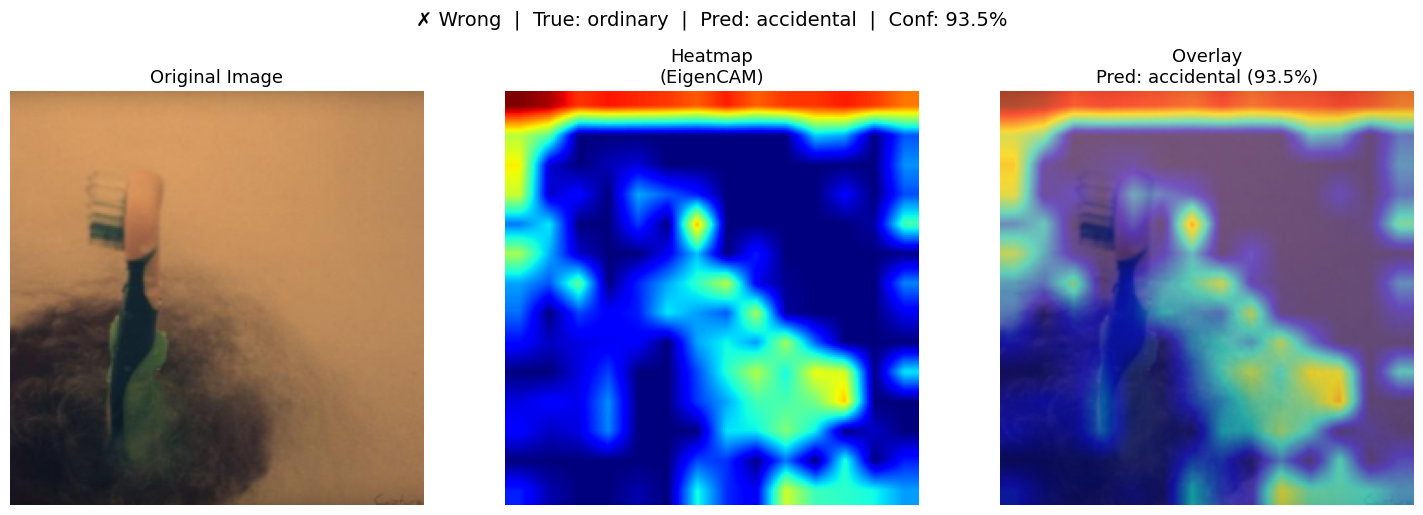


Result: {'image_path': '/content/drive/MyDrive/mgr/colab_test_images/5353.jpg', 'true_label': 'ordinary', 'pred_label': 'accidental', 'confidence': 0.9349097013473511, 'correct': np.False_}
  Loaded: resnet_none.pt
  Architecture: resnet50
  Classes: ['ordinary', 'accidental']
Saved: ../outputs/figures/resnet50.png


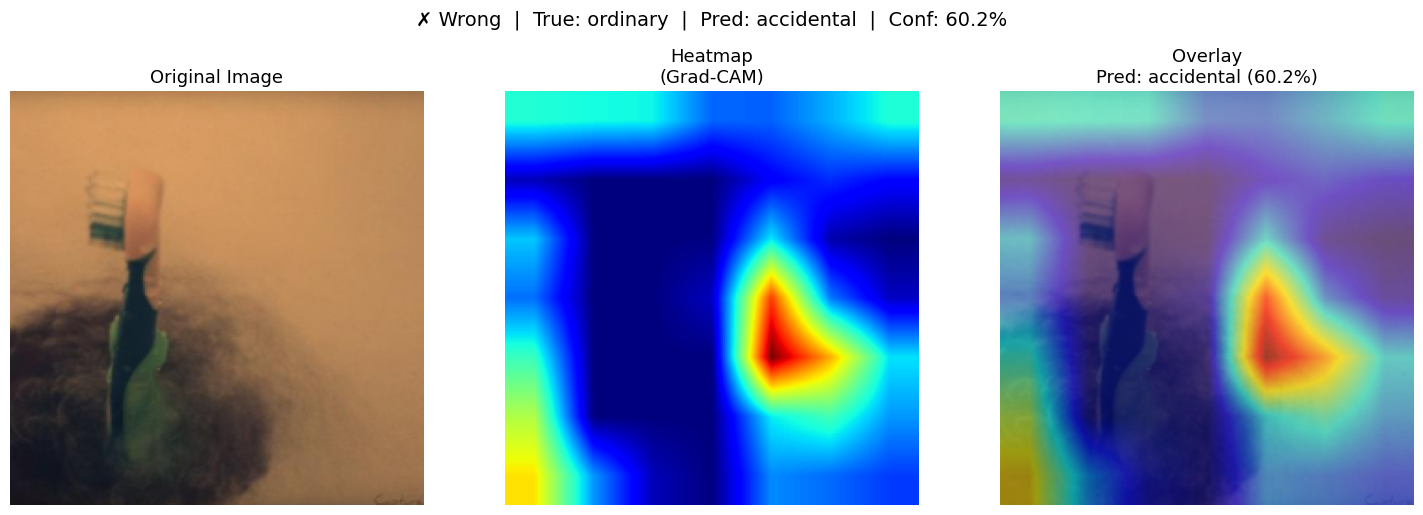


Result: {'image_path': '/content/drive/MyDrive/mgr/colab_test_images/5353.jpg', 'true_label': 'ordinary', 'pred_label': 'accidental', 'confidence': 0.6023191213607788, 'correct': np.False_}


In [17]:

model, model_name, config, label_names = load_model("/content/drive/MyDrive/mgr/models/vit_oversample.pt")

result = generate_explanation(
    model=model,
    model_name=model_name,
    df=test_df,
    index=11,
    save_path=f"../outputs/figures/{model_name}.png"
)

print(f"\nResult: {result}")

model, model_name, config, label_names = load_model("/content/drive/MyDrive/mgr/models/resnet_none.pt")

result = generate_explanation(
    model=model,
    model_name=model_name,
    df=test_df,
    index=11,
    save_path=f"../outputs/figures/{model_name}.png"
)

print(f"\nResult: {result}")

Saved: ../outputs/figures/resnet50.png


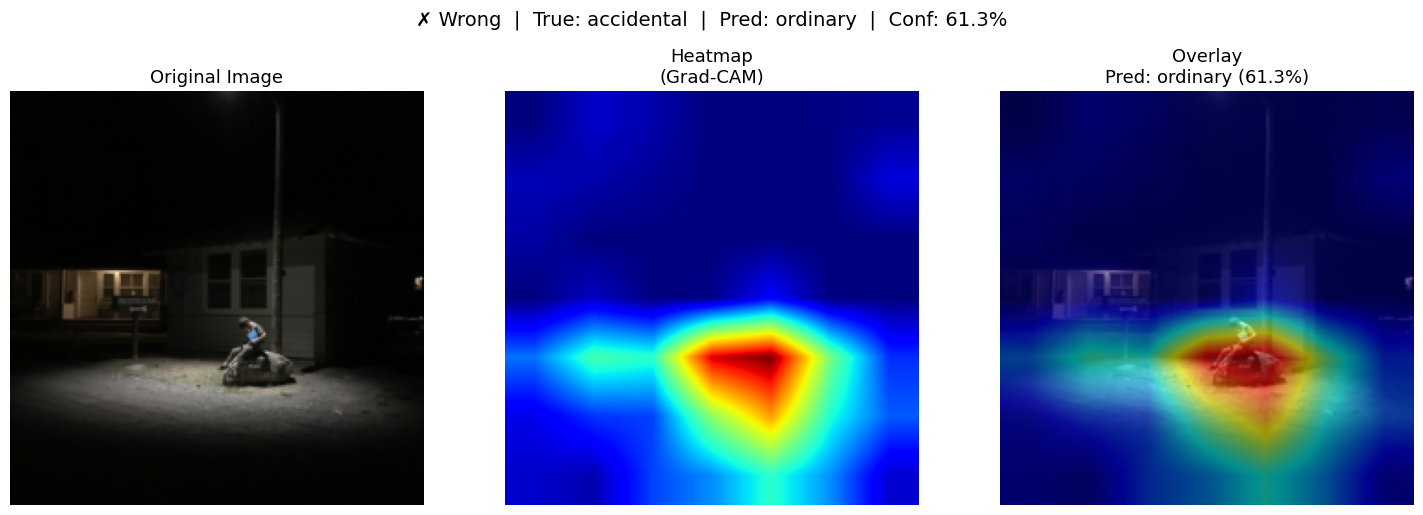


Result: {'image_path': '/content/drive/MyDrive/mgr/colab_test_images/db393dccc3328466.jpg', 'true_label': 'accidental', 'pred_label': 'ordinary', 'confidence': 0.6125046610832214, 'correct': np.False_}
Saved: ../outputs/figures/resnet50.png


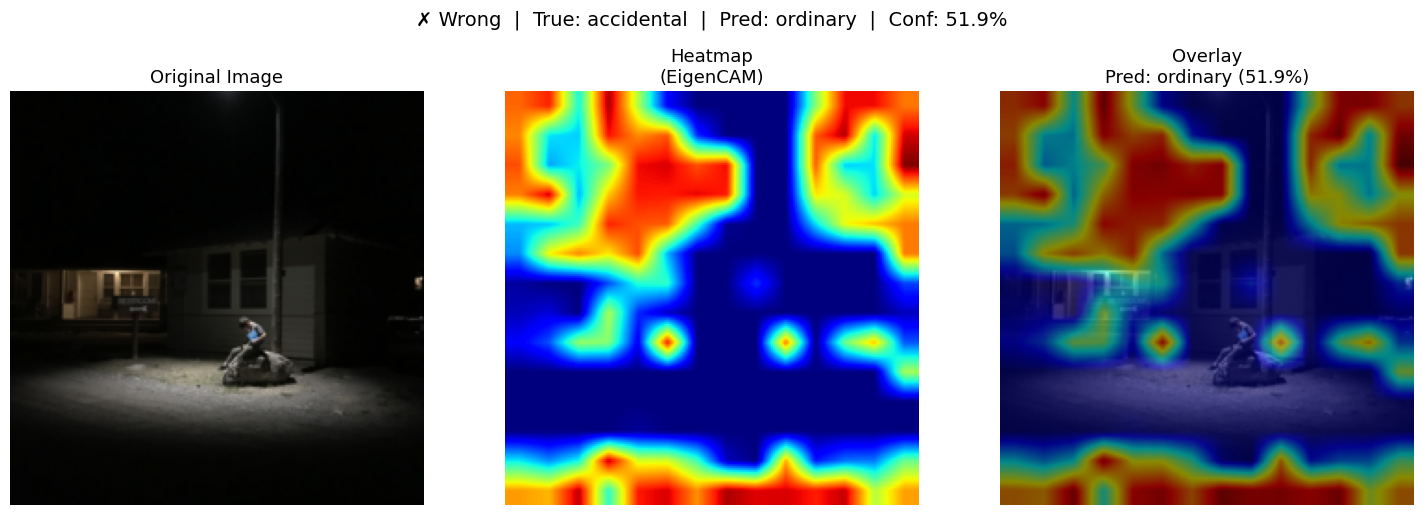


Result: {'image_path': '/content/drive/MyDrive/mgr/colab_test_images/db393dccc3328466.jpg', 'true_label': 'accidental', 'pred_label': 'ordinary', 'confidence': 0.5189484357833862, 'correct': np.False_}


In [18]:
# random_model = resnet50(weights=None)
random_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
random_model.fc = nn.Linear(random_model.fc.in_features, 2)

random_model.eval()

result = generate_explanation(
    model=random_model,
    model_name="random_resnet",
    df=test_df,
    index=34,
    save_path=f"../outputs/figures/{model_name}.png"
)

print(f"\nResult: {result}")

# random_vit = vit_b_16(weights=None)
random_vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
random_vit.heads.head = nn.Linear(
    random_vit.heads.head.in_features,
    2
)

random_vit.eval()

result = generate_explanation(
    model=random_vit,
    model_name="random_vit",
    df=test_df,
    index=34,
    save_path=f"../outputs/figures/{model_name}.png"
)

print(f"\nResult: {result}")

Adding RQ3 Head analysis with dimensionality reduction
________________________________________
PHASE 4 — Representation analysis
This strengthens RQ3 enormously.

Extract embeddings
From final layers of:
ResNet
Vision Transformer
For all three datasets:
•	ordinary
•	accidental
•	paintings

Run UMAP/t-SNE
Visualize:
ordinary ---- accidental ---- paintings
If accidental lies between both domains → very strong finding.
Libraries:
UMAP
________________________________________
PHASE 5 — Domain distance metrics
Optional but very useful.
Compute:
•	cosine distance
•	centroid distance
•	FID
Between:
•	ordinary ↔ accidental
•	accidental ↔ paintings
•	ordinary ↔ paintings


In [19]:
rq1_test_df = load_test_data(
    "/content/drive/MyDrive/mgr/splits/rq1_test_records.csv"
)

rq3_test_df = load_test_data(
    "/content/drive/MyDrive/mgr/splits/rq3_test_records.csv"
)
rq1_subset = rq1_test_df[
    rq1_test_df["label"].isin(
        ["ordinary", "accidental"]
    )
].copy()

rq3_paintings = rq3_test_df[
    rq3_test_df["label"] == "paintings"
].copy()

combined_df = pd.concat(
    [rq1_subset, rq3_paintings],
    ignore_index=True
)

print(len(combined_df))
print(combined_df["label"].value_counts())

  Loaded 853 test samples
  Label distribution:
label
ordinary      687
accidental    166
  Loaded 1374 test samples
  Label distribution:
label
normal       687
paintings    687
1540
label
ordinary      687
paintings     687
accidental    166
Name: count, dtype: int64


In [20]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from pathlib import PureWindowsPath

class EmbeddingDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        self.label_to_index = {
            "ordinary": 0,
            "accidental": 1,
            "paintings": 2
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        filename = PureWindowsPath(
            str(row["path"])
        ).name

        full_path = os.path.join(
            "/content/drive/MyDrive/mgr/colab_test_images",
            filename
        )

        image = Image.open(
            full_path
        ).convert("RGB")

        image = self.transform(image)

        label = self.label_to_index[
            row["label"]
        ]

        return image, label

In [21]:
eval_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

embedding_dataset = EmbeddingDataset(
    combined_df,
    eval_transform
)

embedding_loader = DataLoader(
    embedding_dataset,
    batch_size=32,
    shuffle=False
)

In [22]:
import torch
import numpy as np

def extract_embeddings(model, loader, device, model_type):
    model.eval()

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            # ------------------------
            # ResNet embeddings
            # ------------------------
            if model_type == "resnet":
                x = model.conv1(images)
                x = model.bn1(x)
                x = model.relu(x)
                x = model.maxpool(x)

                x = model.layer1(x)
                x = model.layer2(x)
                x = model.layer3(x)
                x = model.layer4(x)

                x = model.avgpool(x)
                features = torch.flatten(x, 1)

            # ------------------------
            # ViT embeddings
            # ------------------------
            elif model_type == "vit":
                x = model._process_input(images)

                n = x.shape[0]

                batch_class_token = model.class_token.expand(
                    n, -1, -1
                )

                x = torch.cat(
                    [batch_class_token, x],
                    dim=1
                )

                x = model.encoder(x)

                # CLS token embedding
                features = x[:, 0]

            else:
                raise ValueError(
                    f"Unsupported model type: {model_type}"
                )

            all_embeddings.append(
                features.cpu()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    embeddings = torch.cat(
        all_embeddings
    ).numpy()

    return embeddings, np.array(all_labels)

In [23]:
index_to_label = {
    0: "ordinary",
    1: "accidental",
    2: "paintings"
}

In [24]:
def load_model_for_evaluation(model_path, device):
    checkpoint = torch.load(
        model_path,
        map_location=device
    )

    print(f"\nLoading: {os.path.basename(model_path)}")

    # ----------------------------
    # Extract state dict
    # ----------------------------
    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    config = checkpoint.get("config", None)

    # =====================================================
    # CASE 1 → config exists (ideal)
    # =====================================================
    if config is not None:
        print("Using saved config:")
        print(config["model"])

        classifier_keys = [
            k for k in state_dict.keys()
            if (
                ("fc" in k or "heads.head" in k)
                and "weight" in k
            )
        ]

        final_key = sorted(classifier_keys)[-1]
        num_classes = state_dict[final_key].shape[0]

        model = build_model(
            config=config,
            num_classes=num_classes
        ).to(device)

    # =====================================================
    # CASE 2 → fallback for old checkpoints
    # =====================================================
    else:
        print("No config found → inferring architecture")

        # ----------------------------
        # Detect ViT vs ResNet
        # ----------------------------
        if any(k.startswith("heads.head") for k in state_dict.keys()):
            architecture = "vit_b_16"
            print("Detected ViT")

            vit_weight_keys = sorted([
                k for k in state_dict.keys()
                if k.startswith("heads.head") and "weight" in k
            ])

            print("ViT head keys:", vit_weight_keys)

            # -------------------------
            # Single linear head
            # -------------------------
            if len(vit_weight_keys) == 1:
                final_key = vit_weight_keys[0]

                num_classes = state_dict[
                    final_key
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True
                    }
                }

            # -------------------------
            # Sequential head
            # -------------------------
            elif len(vit_weight_keys) >= 2:
                first_key = vit_weight_keys[0]
                final_key = vit_weight_keys[-1]

                hidden_units = state_dict[
                    first_key
                ].shape[0]

                num_classes = state_dict[
                    final_key
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True,
                        "head_hidden": hidden_units,
                        "dropout": 0.5
                    }
                }

            else:
                raise ValueError(
                    f"Unknown ViT structure: {vit_weight_keys}"
                )

        else:
            architecture = "resnet50"
            print("Detected ResNet")

            # sequential head
            if "fc.1.weight" in state_dict:
                hidden_units = state_dict[
                    "fc.1.weight"
                ].shape[0]

                num_classes = state_dict[
                    "fc.4.weight"
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True,
                        "head_hidden": hidden_units,
                        "dropout": 0.5
                    }
                }

            elif "fc.0.weight" in state_dict:
                hidden_units = state_dict[
                    "fc.0.weight"
                ].shape[0]

                num_classes = state_dict[
                    "fc.3.weight"
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True,
                        "head_hidden": hidden_units,
                        "dropout": 0.5
                    }
                }

            else:
                num_classes = state_dict[
                    "fc.weight"
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True
                    }
                }

        print("Reconstructed config:")
        print(config)

        model = build_model(
            config=config,
            num_classes=num_classes
        ).to(device)

    # ----------------------------
    # Load weights
    # ----------------------------
    missing, unexpected = model.load_state_dict(
        state_dict,
        strict=False
    )

    if missing:
        print("Missing keys:", missing)

    if unexpected:
        print("Unexpected keys:", unexpected)

    model.eval()
    return model

In [ ]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


rq3_models = [
    "rq3_resnet_keep_head",
    "rq3_resnet_reset_head",
    "rq3_vit_keep_head",
    "rq3_vit_reset_head"
]

embedding_results = {}

for exp_name in rq3_models:
    print(f"\nRunning UMAP for {exp_name}")

    model_path = os.path.join(
        MODELS_DIR,
        f"{exp_name}.pt"
    )

    model = load_model_for_evaluation(
        model_path,
        device
    )

    model_type = (
        "vit"
        if "vit" in exp_name.lower()
        else "resnet"
    )

    embeddings, labels = extract_embeddings(
        model,
        embedding_loader,
        device,
        model_type
    )

    reducer = umap.UMAP(
        n_neighbors=25,
        min_dist=0.2,
        metric="cosine",
        random_state=42
    )

    reduced = reducer.fit_transform(
        embeddings
    )

    plot_df = pd.DataFrame({
        "x": reduced[:, 0],
        "y": reduced[:, 1],
        "label": [
            index_to_label[i]
            for i in labels
        ]
    })

    embedding_results[exp_name] = {
        "plot_df": plot_df,
        "embeddings": embeddings,
        "labels": labels
    }


Running UMAP for rq3_resnet_keep_head

Loading: rq3_resnet_keep_head.pt
No config found → inferring architecture
Detected ResNet
Reconstructed config:
{'model': {'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.5}}


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Running UMAP for rq3_resnet_reset_head

Loading: rq3_resnet_reset_head.pt
No config found → inferring architecture
Detected ResNet
Reconstructed config:
{'model': {'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True}}


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Running UMAP for rq3_vit_keep_head

Loading: rq3_vit_keep_head.pt
No config found → inferring architecture
Detected ViT
ViT head keys: ['heads.head.1.weight', 'heads.head.4.weight']
Reconstructed config:
{'model': {'name': 'vit_b_16', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.5}}


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Running UMAP for rq3_vit_reset_head

Loading: rq3_vit_reset_head.pt
No config found → inferring architecture
Detected ViT
ViT head keys: ['heads.head.weight']
Reconstructed config:
{'model': {'name': 'vit_b_16', 'pretrained': True, 'freeze_backbone': True}}


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


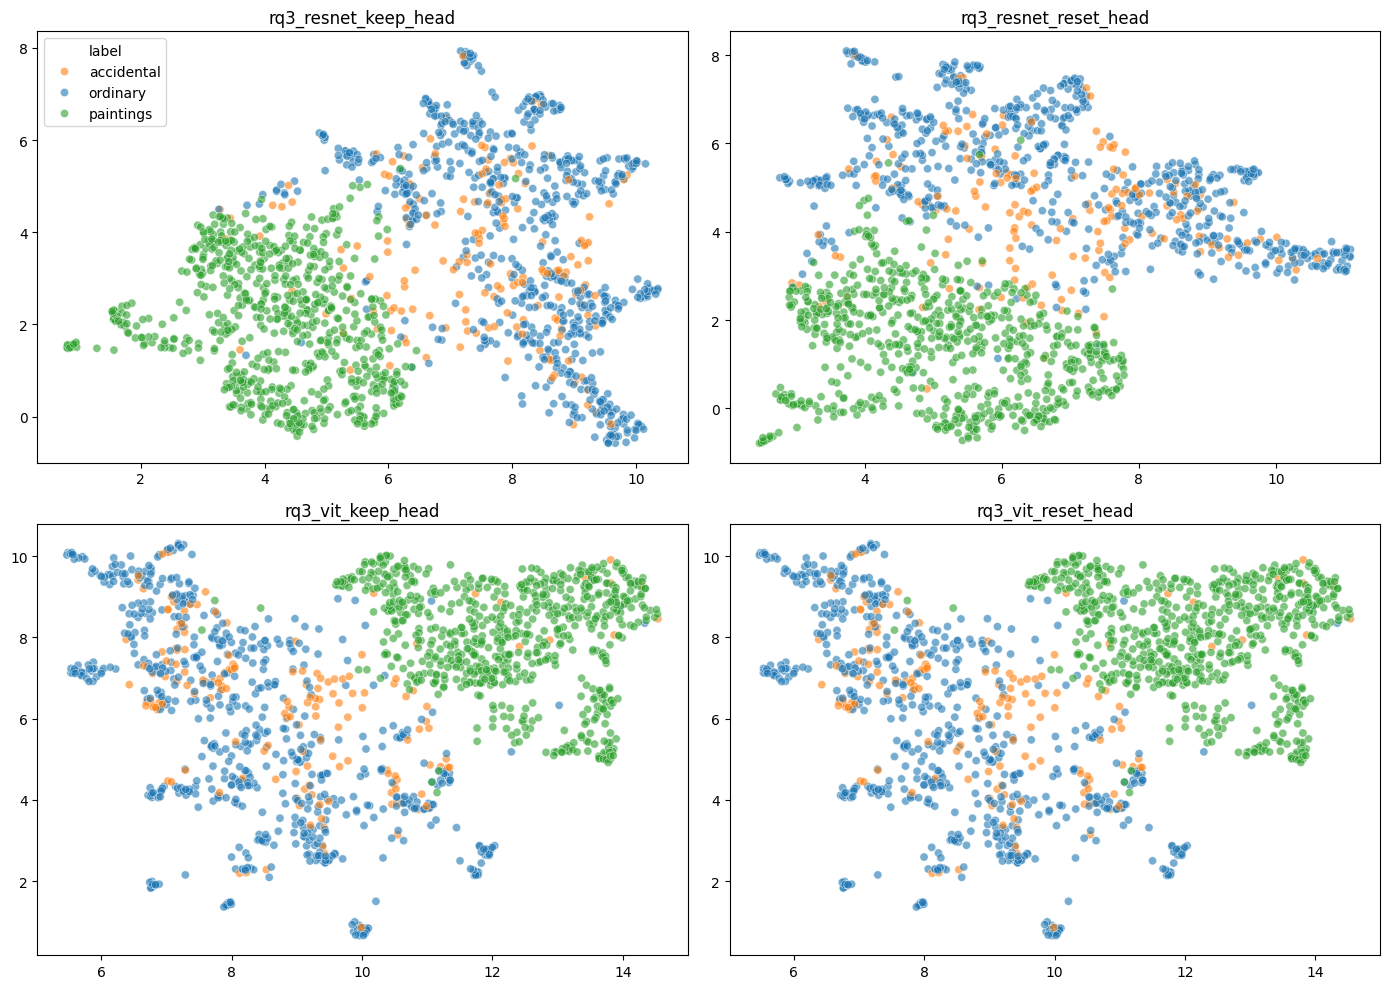

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

axes = axes.flatten()

palette = {
    "ordinary": "#1f77b4",
    "accidental": "#ff7f0e",
    "paintings": "#2ca02c"
}

for i, (exp_name, model_data) in enumerate(embedding_results.items()):
    ax = axes[i]

    plot_df = model_data["plot_df"]

    sns.scatterplot(
        data=plot_df,
        x="x",
        y="y",
        hue="label",
        palette=palette,
        alpha=0.6,
        s=35,
        ax=ax,
        legend=(i == 0)   # only first plot gets legend
    )

    ax.set_title(exp_name)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.spatial.distance import euclidean

def centroid_distance(embeddings, labels, label_mapping):
    results = {}

    centroids = {}

    for label_idx, label_name in label_mapping.items():
        class_embeddings = embeddings[
            labels == label_idx
        ]

        centroids[label_name] = class_embeddings.mean(axis=0)

    pairs = [
        ("ordinary", "accidental"),
        ("accidental", "paintings"),
        ("ordinary", "paintings")
    ]

    for a, b in pairs:
        dist = euclidean(
            centroids[a],
            centroids[b]
        )

        results[f"{a} ↔ {b}"] = dist

    return results

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def cosine_centroid_distance(
    embeddings,
    labels,
    label_mapping
):
    results = {}

    centroids = {}

    for label_idx, label_name in label_mapping.items():
        class_embeddings = embeddings[
            labels == label_idx
        ]

        centroids[label_name] = class_embeddings.mean(axis=0)

    pairs = [
        ("ordinary", "accidental"),
        ("accidental", "paintings"),
        ("ordinary", "paintings")
    ]

    for a, b in pairs:
        sim = cosine_similarity(
            centroids[a].reshape(1, -1),
            centroids[b].reshape(1, -1)
        )[0][0]

        results[f"{a} ↔ {b}"] = 1 - sim

    return results

In [ ]:
from scipy.linalg import sqrtm

def compute_fid(
    embeddings_a,
    embeddings_b
):
    mu1 = np.mean(
        embeddings_a,
        axis=0
    )

    mu2 = np.mean(
        embeddings_b,
        axis=0
    )

    sigma1 = np.cov(
        embeddings_a,
        rowvar=False
    )

    sigma2 = np.cov(
        embeddings_b,
        rowvar=False
    )

    diff = mu1 - mu2

    covmean = sqrtm(
        sigma1.dot(sigma2)
    )

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = (
        diff.dot(diff)
        + np.trace(
            sigma1
            + sigma2
            - 2 * covmean
        )
    )

    return fid

In [ ]:
distance_rows = []

for exp_name, data in embedding_results.items():
    embeddings = data["embeddings"]
    labels = data["labels"]

    centroid_results = centroid_distance(
        embeddings,
        labels,
        index_to_label
    )

    cosine_results = cosine_centroid_distance(
        embeddings,
        labels,
        index_to_label
    )

    ordinary_emb = embeddings[
        labels == 0
    ]

    accidental_emb = embeddings[
        labels == 1
    ]

    painting_emb = embeddings[
        labels == 2
    ]

    fid_results = {
        "ordinary ↔ accidental": compute_fid(
            ordinary_emb,
            accidental_emb
        ),
        "accidental ↔ paintings": compute_fid(
            accidental_emb,
            painting_emb
        ),
        "ordinary ↔ paintings": compute_fid(
            ordinary_emb,
            painting_emb
        )
    }

    distance_rows.append({
        "model": exp_name,

        "centroid_OA": centroid_results[
            "ordinary ↔ accidental"
        ],
        "centroid_AP": centroid_results[
            "accidental ↔ paintings"
        ],
        "centroid_OP": centroid_results[
            "ordinary ↔ paintings"
        ],

        "cosine_OA": cosine_results[
            "ordinary ↔ accidental"
        ],
        "cosine_AP": cosine_results[
            "accidental ↔ paintings"
        ],
        "cosine_OP": cosine_results[
            "ordinary ↔ paintings"
        ],

        "fid_OA": fid_results[
            "ordinary ↔ accidental"
        ],
        "fid_AP": fid_results[
            "accidental ↔ paintings"
        ],
        "fid_OP": fid_results[
            "ordinary ↔ paintings"
        ]
    })

distance_df = pd.DataFrame(
    distance_rows
)

display(distance_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


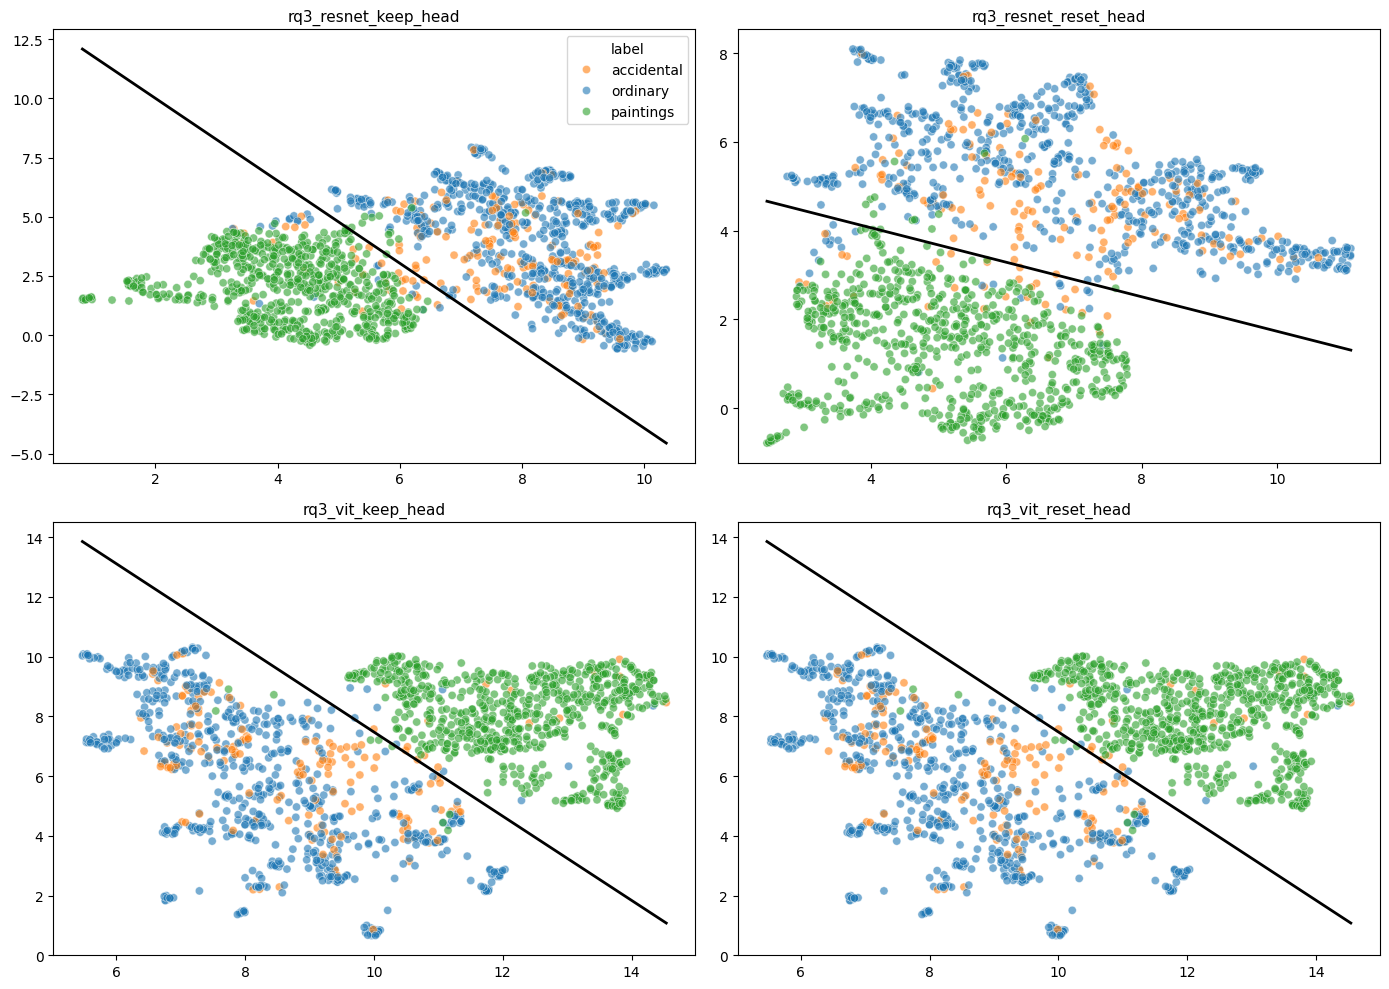

In [ ]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

axes = axes.flatten()

palette = {
    "ordinary": "#1f77b4",
    "accidental": "#ff7f0e",
    "paintings": "#2ca02c"
}

boundary_results = {}

for i, (exp_name, model_data) in enumerate(
    embedding_results.items()
):

    ax = axes[i]

    plot_df = model_data["plot_df"].copy()

    # =====================================
    # Fit boundary using paintings vs ordinary
    # =====================================

    boundary_df = plot_df[
        plot_df["label"].isin(
            ["ordinary", "paintings"]
        )
    ]

    X = boundary_df[
        ["x", "y"]
    ].values

    y = np.where(
        boundary_df["label"] == "paintings",
        1,
        0
    )

    svm = SVC(
        kernel="linear",
        random_state=42
    )

    svm.fit(X, y)

    # =====================================
    # Distance to boundary
    # =====================================

    plot_df["distance_to_boundary"] = (
        svm.decision_function(
            plot_df[["x", "y"]]
        )
    )

    boundary_results[exp_name] = {
        "svm": svm,
        "plot_df": plot_df
    }

    # =====================================
    # Plot points
    # =====================================

    sns.scatterplot(
        data=plot_df,
        x="x",
        y="y",
        hue="label",
        palette=palette,
        alpha=0.6,
        s=35,
        ax=ax,
        legend=(i == 0)
    )

    # =====================================
    # Draw separating line
    # =====================================

    w = svm.coef_[0]
    b = svm.intercept_[0]

    x_min = plot_df["x"].min()
    x_max = plot_df["x"].max()

    x_vals = np.linspace(
        x_min,
        x_max,
        500
    )

    # decision boundary:
    # w0*x + w1*y + b = 0

    if abs(w[1]) > 1e-6:

        y_vals = -(
            w[0] * x_vals + b
        ) / w[1]

        ax.plot(
            x_vals,
            y_vals,
            color="black",
            linewidth=2,
            label="Boundary"
        )

    ax.set_title(
        exp_name,
        fontsize=11
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import PureWindowsPath

reddit_df = pd.read_excel(
    "/content/drive/MyDrive/mgr/splits/reddit_upvotes.xlsx"
)

reddit_df["filename"] = reddit_df["path"].apply(
    lambda x: PureWindowsPath(str(x)).name
)

embedding_filenames = (
    embedding_dataset.df["path"]
    .apply(lambda x: PureWindowsPath(str(x)).name)
    .values
)

In [ ]:
analysis_tables = {}

for exp_name, model_data in boundary_results.items():

    plot_df = model_data["plot_df"].copy()

    plot_df["filename"] = embedding_filenames

    merged = plot_df.merge(
        reddit_df,
        on="filename",
        how="inner"
    )

    analysis_tables[exp_name] = merged

    print(
        exp_name,
        "matched:",
        len(merged)
    )

rq3_resnet_keep_head matched: 166
rq3_resnet_reset_head matched: 166
rq3_vit_keep_head matched: 166
rq3_vit_reset_head matched: 166


In [ ]:
from scipy.stats import spearmanr
import pandas as pd

results = []

for exp_name, merged in analysis_tables.items():

    analysis_df = merged.copy()

    analysis_df = analysis_df.dropna(
        subset=[
            "distance_to_boundary",
            "upvotes"
        ]
    )

    print(
        exp_name,
        "usable rows:",
        len(analysis_df)
    )

    if len(analysis_df) < 10:
        continue

    rho_up, p_up = spearmanr(
        analysis_df["distance_to_boundary"].values,
        analysis_df["upvotes"].values,
        nan_policy="omit"
    )

    rho_comments, p_comments = spearmanr(
        analysis_df["distance_to_boundary"].values,
        analysis_df["comments"].values,
        nan_policy="omit"
    )

    results.append({
        "model": exp_name,
        "n": len(analysis_df),
        "upvotes_rho": rho_up,
        "upvotes_p": p_up,
        "comments_rho": rho_comments,
        "comments_p": p_comments
    })

results_df = pd.DataFrame(results)

display(results_df)

rq3_resnet_keep_head usable rows: 122
rq3_resnet_reset_head usable rows: 122
rq3_vit_keep_head usable rows: 122
rq3_vit_reset_head usable rows: 122


,model,n,upvotes_rho,upvotes_p,comments_rho,comments_p
0,rq3_resnet_keep_head,122,0.122273,0.179696,0.226553,0.012097
1,rq3_resnet_reset_head,122,0.133285,0.143314,0.190430,0.035643
2,rq3_vit_keep_head,122,-0.077970,0.393306,0.028201,0.757822
3,rq3_vit_reset_head,122,-0.077970,0.393306,0.028201,0.757822


In [ ]:
from scipy.spatial.distance import cdist
import numpy as np

centroid_results = {}

for exp_name, model_data in embedding_results.items():

    plot_df = model_data["plot_df"].copy()

    painting_points = plot_df[
        plot_df["label"] == "paintings"
    ][["x", "y"]].values

    ordinary_points = plot_df[
        plot_df["label"] == "ordinary"
    ][["x", "y"]].values

    painting_centroid = painting_points.mean(axis=0)
    ordinary_centroid = ordinary_points.mean(axis=0)

    centroid_results[exp_name] = {
        "painting_centroid": painting_centroid,
        "ordinary_centroid": ordinary_centroid
    }

In [ ]:
from scipy.spatial.distance import euclidean

for exp_name, model_data in embedding_results.items():

    plot_df = model_data["plot_df"].copy()

    painting_centroid = centroid_results[
        exp_name
    ]["painting_centroid"]

    ordinary_centroid = centroid_results[
        exp_name
    ]["ordinary_centroid"]

    coords = plot_df[
        ["x", "y"]
    ].values

    dist_to_painting = np.linalg.norm(
        coords - painting_centroid,
        axis=1
    )

    dist_to_ordinary = np.linalg.norm(
        coords - ordinary_centroid,
        axis=1
    )

    # positive = more painting-like
    plot_df["painting_score"] = (
        dist_to_ordinary -
        dist_to_painting
    )

    centroid_results[exp_name]["plot_df"] = plot_df

In [ ]:
from pathlib import PureWindowsPath

embedding_filenames = (
    embedding_dataset.df["path"]
    .apply(
        lambda x:
        PureWindowsPath(str(x)).name
    )
    .values
)

In [ ]:
analysis_tables_centroid = {}

for exp_name, result in centroid_results.items():

    plot_df = result["plot_df"].copy()

    plot_df["filename"] = embedding_filenames

    merged = plot_df.merge(
        reddit_df,
        on="filename",
        how="inner"
    )

    analysis_tables_centroid[
        exp_name
    ] = merged

    print(
        exp_name,
        len(merged)
    )

In [ ]:
from scipy.stats import spearmanr

results = []

for exp_name, merged in analysis_tables_centroid.items():

    analysis_df = merged.dropna(
        subset=["upvotes"]
    )

    rho_up, p_up = spearmanr(
        analysis_df["painting_score"],
        analysis_df["upvotes"]
    )

    rho_comments, p_comments = spearmanr(
        analysis_df["painting_score"],
        analysis_df["comments"]
    )

    results.append({
        "model": exp_name,
        "n": len(analysis_df),
        "upvotes_rho": rho_up,
        "upvotes_p": p_up,
        "comments_rho": rho_comments,
        "comments_p": p_comments
    })

pd.DataFrame(results)

In [ ]:
best_model = "rq3_vit_reset_head"

df = analysis_tables_centroid[
    best_model
]
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="painting_score",
    y=np.log1p(df["upvotes"])
)

plt.xlabel(
    "Painting-likeness score"
)

plt.ylabel(
    "log(Upvotes + 1)"
)

plt.title(
    "Painting-likeness vs Reddit upvotes"
)

plt.show()

In [ ]:
df["upvote_quartile"] = pd.qcut(
    df["upvotes"],
    4,
    labels=["Q1","Q2","Q3","Q4"]
)

df["comment_quartile"] = pd.qcut(
    df["comments"],
    4,
    labels=["Q1","Q2","Q3","Q4"]
)


In [ ]:
print(df.groupby(
    "upvote_quartile"
)["painting_score"].agg(
    ["count","mean","median","std"]
))

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="upvote_quartile",
    y="painting_score"
)

plt.xlabel("Upvote quartile")
plt.ylabel("Painting-likeness score")
plt.title("Painting-likeness across Reddit popularity groups")

plt.show()

In [ ]:

print(df.groupby(
    "comment_quartile"
)["painting_score"].agg(
    ["count","mean","median","std"]
))

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="comment_quartile",
    y="painting_score"
)

plt.xlabel("Comment quartile")
plt.ylabel("Painting-likeness score")
plt.title("Painting-likeness across Reddit popularity groups")

plt.show()

In [ ]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 12)
)

axes = axes.flatten()

boundary_results = {}

last_scatter = None

for i, (exp_name, model_data) in enumerate(
    embedding_results.items()
):

    ax = axes[i]

    plot_df = model_data["plot_df"].copy()

    # =====================================
    # Add filenames
    # =====================================

    plot_df["filename"] = embedding_filenames

    plot_df = plot_df.merge(
        reddit_df[
            ["filename", "upvotes", "comments"]
        ],
        on="filename",
        how="left"
    )

    # =====================================
    # Train boundary
    # =====================================

    boundary_df = plot_df[
        plot_df["label"].isin(
            ["ordinary", "paintings"]
        )
    ]

    X = boundary_df[
        ["x", "y"]
    ].values

    y = np.where(
        boundary_df["label"] == "paintings",
        1,
        0
    )

    svm = SVC(
        kernel="linear",
        random_state=42
    )

    svm.fit(X, y)

    # =====================================
    # Save distance
    # =====================================

    plot_df["distance_to_boundary"] = (
        svm.decision_function(
            plot_df[["x", "y"]]
        )
    )

    boundary_results[exp_name] = {
        "svm": svm,
        "plot_df": plot_df
    }

    # =====================================
    # Ordinary photos
    # =====================================

    ordinary = plot_df[
        plot_df["label"] == "ordinary"
    ]

    ax.scatter(
        ordinary["x"],
        ordinary["y"],
        color="#1f77b4",
        alpha=0.35,
        s=25,
        label="Ordinary"
    )

    # =====================================
    # Paintings
    # =====================================

    paintings = plot_df[
        plot_df["label"] == "paintings"
    ]

    ax.scatter(
        paintings["x"],
        paintings["y"],
        color="#2ca02c",
        alpha=0.35,
        s=25,
        label="Paintings"
    )

    # =====================================
    # Accidental Renaissance
    # =====================================

    accidental = plot_df[
        plot_df["label"] == "accidental"
    ].copy()

    known = accidental[
        accidental["upvotes"].notna()
    ].copy()

    unknown = accidental[
        accidental["upvotes"].isna()
    ].copy()

    # Missing Reddit data
    ax.scatter(
        unknown["x"],
        unknown["y"],
        color="lightgray",
        s=45,
        alpha=0.8,
        label="No Reddit data"
    )

    # Known Reddit data
    known["upvotes_plot"] = np.log1p(
        known["upvotes"]
    )

    last_scatter = ax.scatter(
        known["x"],
        known["y"],
        c=known["upvotes_plot"],
        cmap="Reds",
        s=70,
        edgecolor="black",
        linewidth=0.3
    )

    # =====================================
    # Draw boundary
    # =====================================

    w = svm.coef_[0]
    b = svm.intercept_[0]

    x_min = plot_df["x"].min()
    x_max = plot_df["x"].max()

    x_vals = np.linspace(
        x_min,
        x_max,
        500
    )

    if abs(w[1]) > 1e-6:

        y_vals = -(
            w[0] * x_vals + b
        ) / w[1]

        ax.plot(
            x_vals,
            y_vals,
            color="black",
            linewidth=2
        )

    ax.set_title(
        exp_name,
        fontsize=12
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

# =====================================
# Shared colorbar
# =====================================

cbar = fig.colorbar(
    last_scatter,
    ax=axes,
    shrink=0.85
)

cbar.set_label(
    "log(upvotes + 1)"
)

plt.tight_layout()
plt.show()